## Postlab

Dataset Shape: (891, 12)
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                      │ (None, 16)                  │             112 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 8)                   │             136 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 1)                   │               9 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 257 (1.00 KB)

 Trainable params: 257 (1.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.6643 - loss: 0.6833 - val_accuracy: 0.7063 - val_loss: 0.6586
Epoch 2/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6960 - loss: 0.6593 - val_accuracy: 0.7133 - val_loss: 0.6377
Epoch 3/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7083 - loss: 0.6334 - val_accuracy: 0.7063 - val_loss: 0.6120
Epoch 4/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7329 - loss: 0.6002 - val_accuracy: 0.7203 - val_loss: 0.5775
Epoch 5/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7610 - loss: 0.5570 - val_accuracy: 0.7622 - val_loss: 0.5353
Epoch 6/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7873 - loss: 0.5191 - val_accuracy: 0.7972 - val_loss: 0.5049
Epoch 7/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7926 - loss: 0.4911 - val_accuracy: 0.8112 - val_loss: 0.4801
Epoch 8/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7996 - loss: 0.4682 - val_accuracy: 0.8042 - val_loss

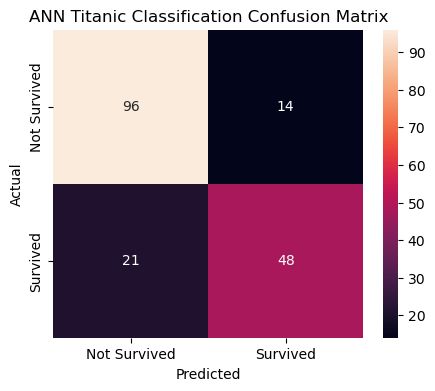

In [2]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Load Titanic Dataset
titanic_url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(titanic_url)

print("Dataset Shape:", df.shape)
print(df.head())

# Select useful features
X = df[['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare']].copy()
y = df['Survived']

# Convert Sex into numeric values
X['Sex'] = X['Sex'].map({'male': 0, 'female': 1})

# Handle missing values
imputer = SimpleImputer(strategy='median')
X = imputer.fit_transform(X)

# Standardize features
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print("Training Set:", X_train.shape)
print("Testing Set:", X_test.shape)

# Build ANN model
ann_titanic = Sequential([
    Dense(16, activation='relu', input_shape=(6,)),
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')
])

# Display model
ann_titanic.summary()

# Compile model
ann_titanic.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Train model
history_titanic = ann_titanic.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=16,
    validation_split=0.2,
    verbose=1
)

print("Model training completed.")

# Predict
y_pred_prob = ann_titanic.predict(X_test)
y_pred = (y_pred_prob >= 0.5).astype(int)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("\nANN Test Accuracy:", accuracy * 100, "%")

# Classification report
print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=['Not Survived', 'Survived']
    )
)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=['Not Survived', 'Survived'],
    yticklabels=['Not Survived', 'Survived']
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("ANN Titanic Classification Confusion Matrix")
plt.show()